In [6]:
#Step One - load the excel file

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from collections import Counter

file_path = "_github-AAC_accidents_tagged_data.xlsx"
df = pd.read_excel(file_path, sheet_name="data")


In [7]:
!pip install geopy

THE FOLLOWING CODE IS FOR THE SPATIAL ANALYSIS TASK. I have included my steps to complete this using our create tags.

FIRST TASK - (From Proposal) Because the dataset includes location information, we will perform spatial analysis of accidents across North America. We converted the descriptive locations into GPS/Lat-Long coordinates to plot the accident locations on a map of North America using scatter plots. We also created a heatmap of North America showing the accident density by region. To determine whether certain climbing disciplines, like rock, alpine, ice and mountaineering, differ in specific locations, the heat map can help show this. This type of analysis will allow us to identify regions with high accident numbers and whether there is a correlation with location and accidents.

Step 1: load the CSV file ANAC_loc

Step 2: inspect the data

Step 3: assign approximate latitude/longitude using a dictionary of state/province center points. This saves time instead of going through every row and applying a specific lat/long. 

Step 4: make a scatter map of North America

Step 5: make a density heatmap

Step 6: use the tags that our group made to compare location patterns for rock, alpine, ice, and mountaineering accidents/'

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df = pd.read_csv("ANAC_loc.csv")

print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns)

df.head()

df[["Accident Title", "Publication Year", "Tags Applied", "Country", "State_Province"]].head(10)

Shape of dataset: (2770, 7)

Columns:
Index(['ID', 'Accident Title', 'Publication Year', 'Text', 'Tags Applied',
       'Country', 'State_Province'],
      dtype='object')


,Accident Title,Publication Year,Tags Applied,Country,State_Province
0,"Failure of Rappel—Failure to Check System, Bri...",1990.0,"Experienced, Serious, Descent, Roped, Top-Rope...",CA,British Columbia
1,"Fall into Crevasse, Climbing Alone, Inadequate...",1990.0,"Experienced, Minor, Unroped , Solo, Climbing A...",CA,Alberta
2,"Fall into Crevasse, Climbing Unroped, British ...",1990.0,"Minor, Unroped , Solo, Alpine/Mountaineering, ...",CA,British Columbia
3,"Fall Into Crevasse, Unroped, Inadequate Equipm...",1990.0,"Deadly, Serious, Descent, Unroped , Solo, Non-...",CA,Alberta
4,"Fall into Moat, Descending Unroped, Poor Posit...",1990.0,"Deadly, Descent, Unroped , Solo, Alpine/Mounta...",CA,Alberta
5,"Fall on Rock, Chocks Pulled Out, Quebec, Gatin...",1990.0,"Serious, Roped, Trad Climbing, Inadequate Prot...",CA,Quebec
6,"Fall on Rock, Climbing Solo, No Hard Hat, Inex...",1990.0,"No/Little, Deadly, Serious, Unroped , Solo, No...",CA,British Columbia
7,"Fall on Rock, Climbing Solo, No Hard Hat, Queb...",1990.0,"Deadly, Serious, Unroped , Solo, No Helmet, La...",CA,Quebec
8,"Fall on Rock, Inadequate Protection, Alberta, ...",1990.0,"Experienced, Serious, Roped, Trad Climbing, In...",CA,Alberta
9,"Fall on Rock, Inadequate Protection, Ontario, ...",1990.0,"Serious, Head / Brain Injury, Roped, Trad Clim...",CA,Ontario


In [9]:
#Because exact GPS coordinates are not in the file, we use approximate center points for each region.

state_coords = {
    "Alaska": (64.2008, -149.4937),
    "Alberta": (53.9333, -116.5765),
    "Arizona": (34.0489, -111.0937),
    "Arkansas": (35.2010, -91.8318),
    "British Columbia": (53.7267, -127.6476),
    "California": (36.7783, -119.4179),
    "Colorado": (39.5501, -105.7821),
    "Connecticut": (41.6032, -73.0877),
    "Georgia": (32.1656, -82.9001),
    "Idaho": (44.0682, -114.7420),
    "Illinois": (40.6331, -89.3985),
    "Kentucky": (37.8393, -84.2700),
    "Maine": (45.2538, -69.4455),
    "Maryland": (39.0458, -76.6413),
    "Massachusetts": (42.4072, -71.3824),
    "Michigan": (44.3148, -85.6024),
    "Minnesota": (46.7296, -94.6859),
    "Missouri": (37.9643, -91.8318),
    "Montana": (46.8797, -110.3626),
    "Nevada": (38.8026, -116.4194),
    "New Brunswick": (46.5653, -66.4619),
    "New Hampshire": (43.1939, -71.5724),
    "New Jersey": (40.0583, -74.4057),
    "New Mexico": (34.5199, -105.8701),
    "New York": (43.0000, -75.0000),
    "North Carolina": (35.7596, -79.0193),
    "Northwest Territories": (64.8255, -124.8457),
    "Nova Scotia": (44.6820, -63.7443),
    "Ohio": (40.4173, -82.9071),
    "Oklahoma": (35.0078, -97.0929),
    "Ontario": (50.0000, -85.0000),
    "Oregon": (43.8041, -120.5542),
    "Pennsylvania": (41.2033, -77.1945),
    "Puebla": (19.0414, -98.2063),
    "Quebec": (52.9399, -73.5491),
    "South Dakota": (43.9695, -99.9018),
    "Tennessee": (35.5175, -86.5804),
    "Texas": (31.9686, -99.9018),
    "Utah": (39.3210, -111.0937),
    "Vermont": (44.5588, -72.5778),
    "Veracruz": (19.1738, -96.1342),
    "Virginia": (37.4316, -78.6569),
    "Washington": (47.7511, -120.7401),
    "West Virginia": (38.5976, -80.4549),
    "Wisconsin": (43.7844, -88.7879),
    "Wyoming": (43.0760, -107.2903),
    "Yukon": (64.2823, -135.0000),
    "Baffin Island": (69.0000, -72.0000)
}

In [11]:
#Assign latitude and longitude to each accident
#in the sample table below, the duplicate locations is because an accident occurred more than once in that region. 

df["Latitude"] = df["State_Province"].map(lambda x: state_coords.get(x, (None, None))[0])
df["Longitude"] = df["State_Province"].map(lambda x: state_coords.get(x, (None, None))[1])

map_df = df.dropna(subset=["Latitude", "Longitude"]).copy()

print("Rows with coordinates:", len(map_df))
map_df[["State_Province", "Country", "Latitude", "Longitude"]].head(10)

Rows with coordinates: 2769


,State_Province,Country,Latitude,Longitude
0,British Columbia,CA,53.7267,-127.6476
1,Alberta,CA,53.9333,-116.5765
2,British Columbia,CA,53.7267,-127.6476
3,Alberta,CA,53.9333,-116.5765
4,Alberta,CA,53.9333,-116.5765
5,Quebec,CA,52.9399,-73.5491
6,British Columbia,CA,53.7267,-127.6476
7,Quebec,CA,52.9399,-73.5491
8,Alberta,CA,53.9333,-116.5765
9,Ontario,CA,50.0000,-85.0000


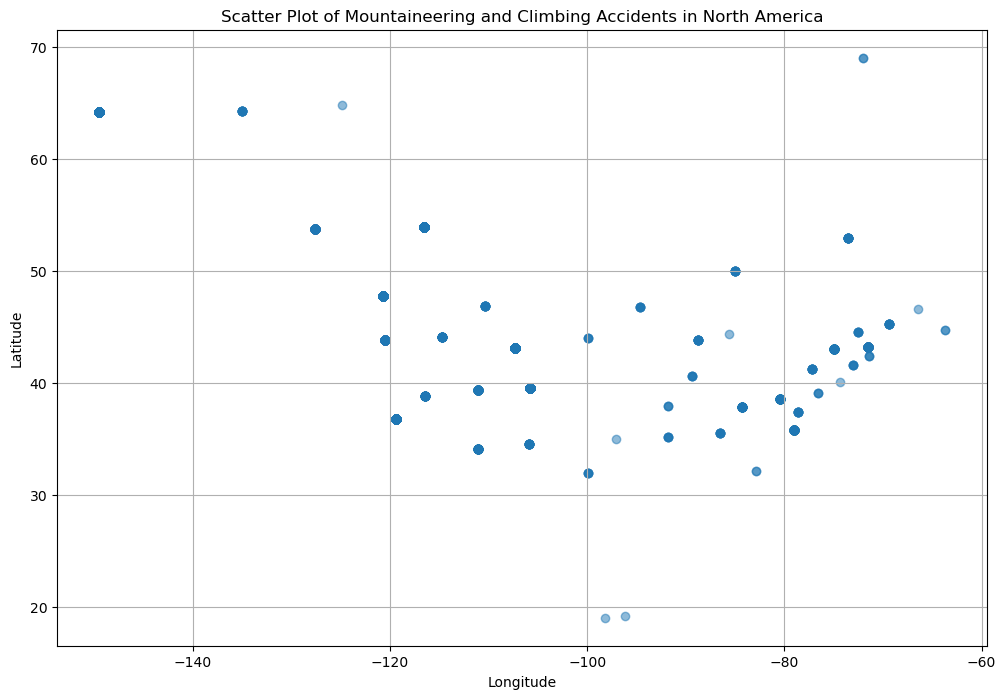

In [12]:
plt.figure(figsize=(12, 8))

plt.scatter(
    map_df["Longitude"],
    map_df["Latitude"],
    alpha=0.5
)

plt.title("Scatter Plot of Mountaineering and Climbing Accidents in North America")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)

plt.show()

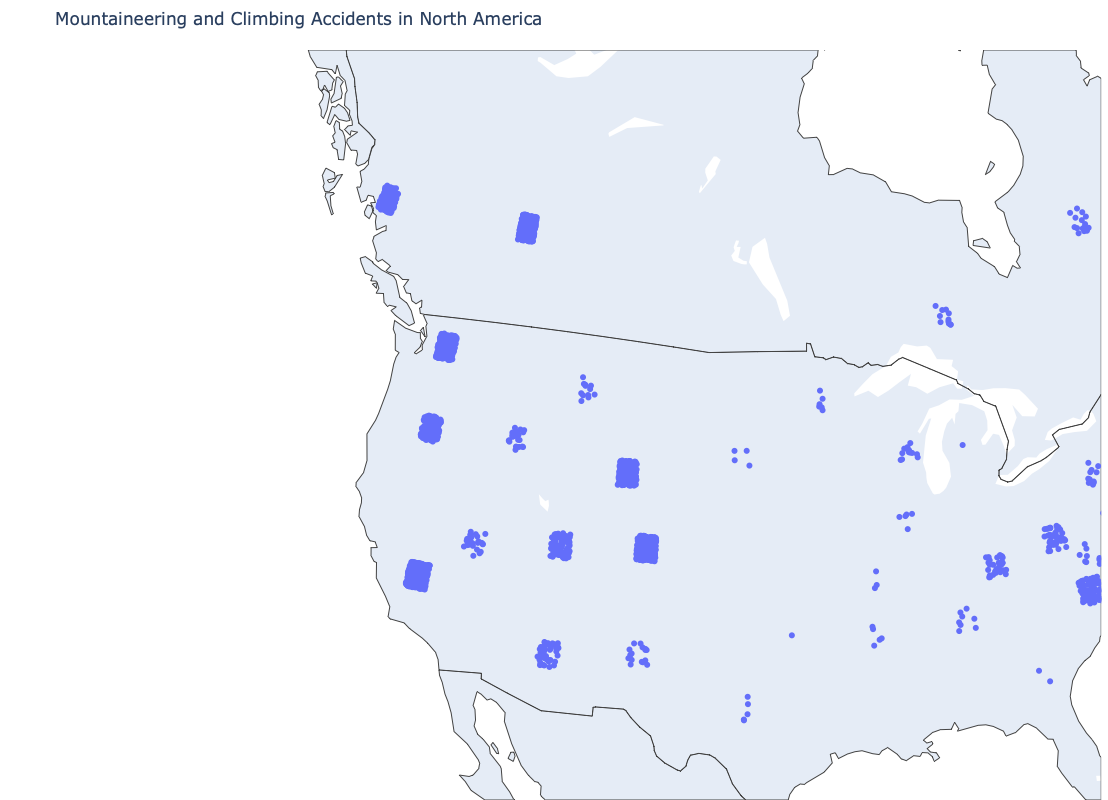

In [17]:
np.random.seed(42)

map_df["Latitude_jitter"] = map_df["Latitude"] + np.random.uniform(-0.6, 0.6, len(map_df))
map_df["Longitude_jitter"] = map_df["Longitude"] + np.random.uniform(-0.6, 0.6, len(map_df))

fig = px.scatter_geo(
    map_df,
    lat="Latitude_jitter",
    lon="Longitude_jitter",
    scope="north america",
    hover_name="Accident Title",
    hover_data=["State_Province", "Country", "Publication Year"],
    title="Mountaineering and Climbing Accidents in North America"
)

fig.update_layout(
    width=1200,
    height=800,
    margin={"r": 0, "t": 50, "l": 0, "b": 0}
)

fig.update_geos(
    projection_scale=2.7,
)

fig.show()

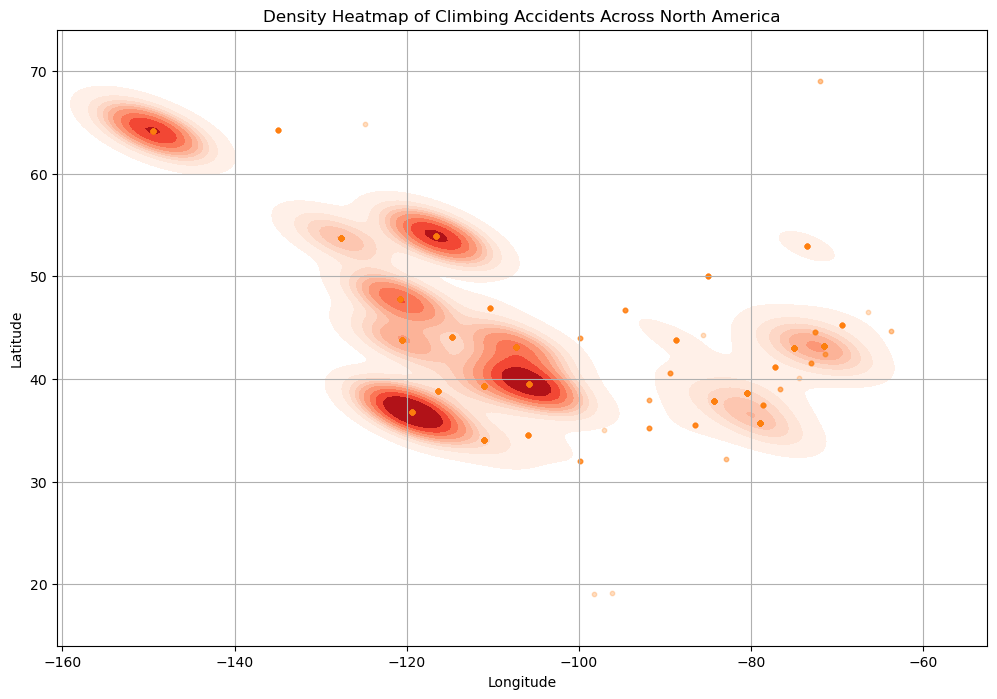

In [18]:
plt.figure(figsize=(12, 8))

sns.kdeplot(
    data=map_df,
    x="Longitude",
    y="Latitude",
    fill=True,
    cmap="Reds",
    bw_adjust=0.7
)

plt.scatter(
    map_df["Longitude"],
    map_df["Latitude"],
    s=10,
    alpha=0.25
)

plt.title("Density Heatmap of Climbing Accidents Across North America")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)

plt.show()

In [20]:
from collections import Counter

all_tags = []

for item in df["Tags Applied"].dropna():
    split_tags = [tag.strip() for tag in str(item).split(",")]
    all_tags.extend(split_tags)

tag_counts = Counter(all_tags)

print("Most common tags:")
print(tag_counts.most_common(30))

df["Rock"] = df["Tags Applied"].str.contains("Trad|Sport|Top-Rope|Bouldering|Rock", case=False, na=False)
df["Alpine"] = df["Tags Applied"].str.contains("Alpine", case=False, na=False)
df["Ice"] = df["Tags Applied"].str.contains("Ice", case=False, na=False)
df["Mountaineering"] = df["Tags Applied"].str.contains("Mountaineering", case=False, na=False)

map_df = df.dropna(subset=["Latitude", "Longitude"]).copy()


print(df[["Tags Applied", "Rock", "Alpine", "Ice", "Mountaineering"]].head(10))


discipline_counts = {
    "Rock": df["Rock"].sum(),
    "Alpine": df["Alpine"].sum(),
    "Ice": df["Ice"].sum(),
    "Mountaineering": df["Mountaineering"].sum()
}


Most common tags:
[('Serious', 1880), ('Roped', 1592), ('Alpine/Mountaineering', 1273), ('Trad Climbing', 902), ('Descent', 879), ('No/Little', 630), ('Inadequate Protection / Pulled', 606), ('Experienced', 588), ('Unroped', 580), ('Head / Brain Injury', 565), ('Deadly', 563), ('Solo', 536), ('Stranded / Lost / Overdue', 325), ('Minor', 261), ('Rappel Error', 255), ('No Helmet', 252), ('Inadequate Equipment', 245), ('Exposure', 244), ('Off-route', 243), ('Visibility', 241), ('Severe Weather', 234), ('Ice Climbing', 223), ('Fatigue', 181), ('Sport', 173), ('Late in Day', 167), ('Climbing Alone', 166), ('Object Dropped/Dislodged', 163), ('Handhold/Foothold Broke', 147), ('Poor Position', 143), ('Anchor Failure / Error', 136)]
                                        Tags Applied   Rock  Alpine    Ice  \
0  Experienced, Serious, Descent, Roped, Top-Rope...   True   False  False   
1  Experienced, Minor, Unroped , Solo, Climbing A...  False    True   True   
2  Minor, Unroped , Solo, Alpine

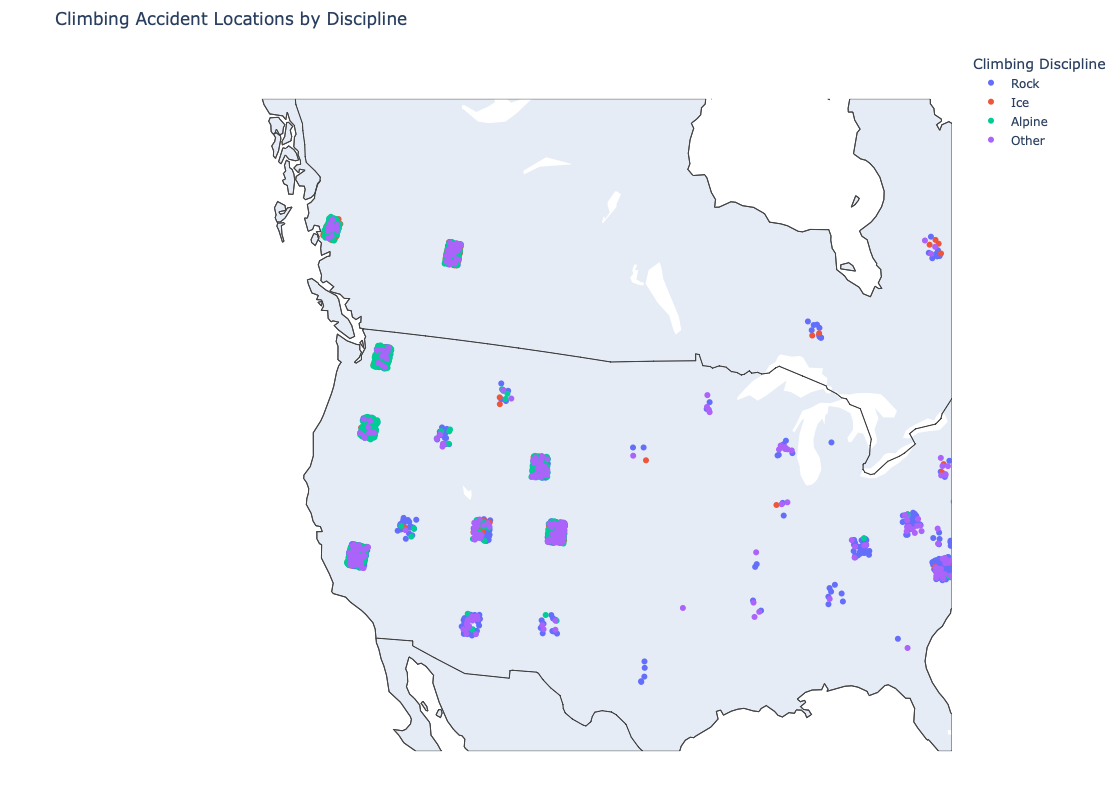

In [22]:

def get_discipline(row):
    
    if row["Ice"]:
        return "Ice"
    elif row["Alpine"]:
        return "Alpine"
    elif row["Mountaineering"]:
        return "Mountaineering"
    elif row["Rock"]:
        return "Rock"
    else:
        return "Other"

map_df["Discipline"] = map_df.apply(get_discipline, axis=1)

# added jitter so points don't overlap
np.random.seed(42)

map_df["Latitude_jitter"] = map_df["Latitude"] + np.random.uniform(-0.6, 0.6, len(map_df))
map_df["Longitude_jitter"] = map_df["Longitude"] + np.random.uniform(-0.6, 0.6, len(map_df))

fig = px.scatter_geo(
    map_df,
    lat="Latitude_jitter",
    lon="Longitude_jitter",
    color="Discipline",
    scope="north america",
    hover_name="Accident Title",
    hover_data=["State_Province", "Country", "Publication Year"],
    title="Climbing Accident Locations by Discipline"
)

fig.update_layout(
    width=1200,
    height=800,
    legend_title="Climbing Discipline",
    margin={"r":0,"t":50,"l":0,"b":0}
)

fig.update_geos(
    projection_scale=2.7,
    showcountries=True,
    showcoastlines=True
)

fig.show()

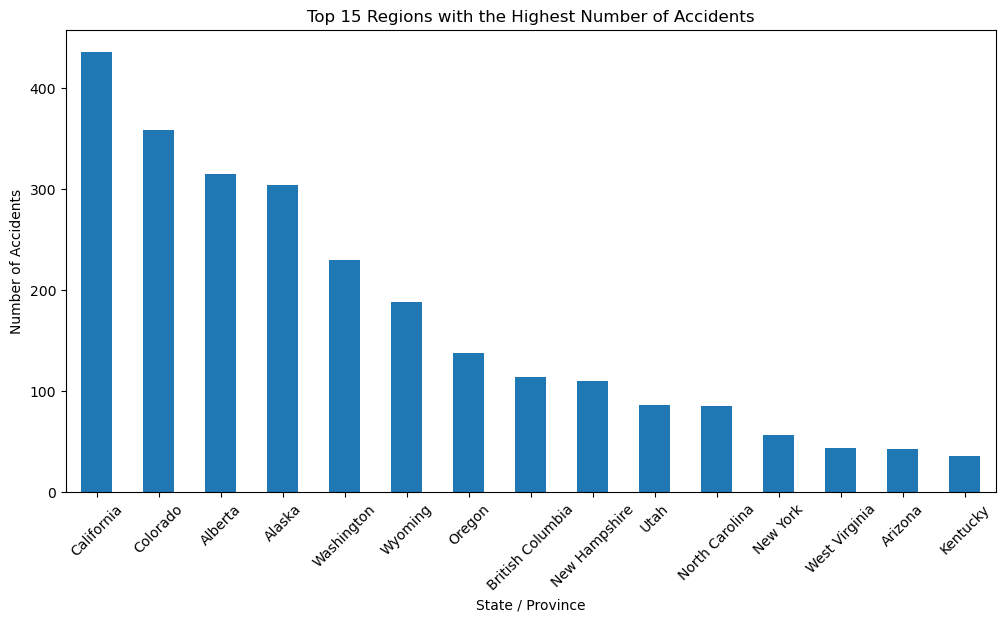

In [23]:
counts_per_region = map_df["State_Province"].value_counts().head(15)

plt.figure(figsize=(12, 6))
counts_per_region.plot(kind="bar")

plt.title("Top 15 Regions with the Highest Number of Accidents")
plt.xlabel("State / Province")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)

plt.show()

Spatial Analysis of Mountaineering and Climbing Accidents
Because the dataset includes location information in the form of country and state/province, spatial analysis was performed across North America. Exact GPS coordinates were not available in the dataset, so approximate latitude and longitude values were assigned using the center point of each state or province. These coordinates were then used to create scatter plots and density heatmaps of accidents across North America. In addition, the tags created by our classmate were used to group accidents into broad climbing disciplines such as rock, alpine, ice, and mountaineering. This allows us to explore whether certain accident types appear to cluster in particular geographic regions.